In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

In [10]:
SCENARIOS = ["1", "2", "3", "4a", "4b", "4_upper_bound"]
N_ENTRIES = ["1M", "10M", "50M", "100M"]

n_entries2numeric = {
    # "10k": 10_000,
    "1M": 1_000_000,
    "10M": 10_000_000,
    "50M": 50_000_000,
    "100M": 100_000_000
}

df = pd.DataFrame()
for s in SCENARIOS:
    for i, n_entries in enumerate(N_ENTRIES):
        walltime = np.loadtxt(f"./results/scenario{s}/{n_entries}.csv", delimiter=",", skiprows=1, usecols=2)
        row = {"scenario": [s], "n_entries": [n_entries2numeric[n_entries]], "walltime_mean": [walltime.mean() * 1e-6], "walltime_std": [walltime.std() * 1e-6]}
        df = pd.concat([df, pd.DataFrame(row)])
        
    
df.reset_index(drop=True, inplace=True)
df = df.pivot(index="n_entries", columns="scenario")
df

walltime_mean                                                        \
scenario              1         2         3 4_upper_bound        4a        4b   
n_entries                                                                       
1000000        0.140694  0.152514  0.151265      0.314860  0.166782  0.168650   
10000000       0.407885  0.449266  0.492558      1.822361  0.550739  0.561203   
50000000       1.363313  1.750455  1.839669      8.580021  2.353863  2.454479   
100000000      2.573036  3.273787  3.654969     17.375685  4.386577  4.761517   

          walltime_std                                                        
scenario             1         2         3 4_upper_bound        4a        4b  
n_entries                                                                     
1000000       0.002680  0.003171  0.002428      0.002684  0.002056  0.002873  
10000000      0.006096  0.006987  0.001584      0.054667  0.003671  0.002355  
50000000      0.003471  0.021936  0.025262      0.388067  0.024370  0.008617  
100000000     0.034353  0.058609  0.037569      0.741783  0.067388  0.041511

In [12]:
df_mean_diff = df.walltime_mean

for col in SCENARIOS:
    df_mean_diff[col] = 1 - (df.walltime_mean["1"] / df_mean_diff[col])
    
df_mean_diff

/tmp/ipykernel_18662/4036383611.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_mean_diff[col] = 1 - (df.walltime_mean["1"] / df_mean_diff[col])


scenario,1,2,3,4_upper_bound,4a,4b
n_entries,,,,,,
1000000,0.0,0.077504,0.069888,0.553154,0.156423,0.165763
10000000,0.0,0.092108,0.171904,0.776177,0.259385,0.273195
50000000,0.0,0.221167,0.258936,0.841106,0.420819,0.444561
100000000,0.0,0.214049,0.296017,0.851917,0.413430,0.459618


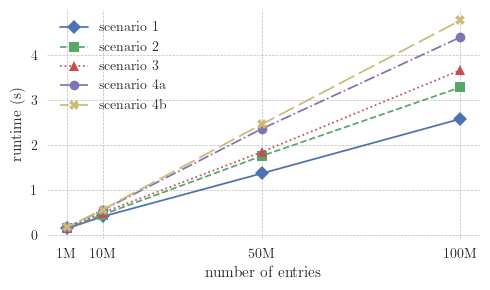

In [14]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "axes.facecolor": "#FFFFFF",
    "axes.grid": True,
    "axes.grid.which": "major",
    "axes.grid.axis": "both",
    "axes.spines.bottom": True,
    "axes.spines.left": True,
    "axes.spines.right": True,
    "axes.spines.top": True,
    "grid.color": "#BBBBBB",
    "grid.linestyle": "--",
    "grid.linewidth": .5,
    "figure.frameon": True
})

fig, ax = plt.subplots(figsize=(5,3))
# ax.set_xscale("log")
ax.set_xticks(df.index, labels=n_entries2numeric.keys())
ax.set_xlabel("number of entries")
ax.set_ylabel("runtime (s)")

linestyles = ["solid", "dashed", "dotted", "dashdot", (5, (10, 3))]
markers = ["D", "s", "^", "o", "X"]
for i, s in enumerate(["1", "2", "3", "4a", "4b"]):
    ax.plot(df.walltime_mean[s],
            linestyle=linestyles[i],
            linewidth=1.25,
            marker=markers[i]
           )

ax.legend(["scenario 1", "scenario 2", "scenario 3", "scenario 4a", "scenario 4b"])

fig.tight_layout()
fig.savefig("plots/runtime_plot.pdf", transparent=True)
fig.savefig("plots/runtime_plot.png", transparent=True)
fig.savefig("plots/runtime_plot.tex", format="pgf", transparent=True)

In [ ]:
def 

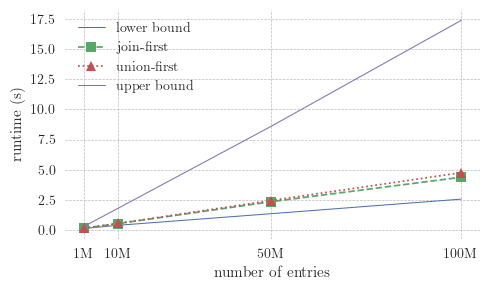

In [21]:
fig, ax = plt.subplots(figsize=(5,3))
# ax.set_xscale("log")
ax.set_xticks(df.index, labels=n_entries2numeric.keys())
ax.set_xlabel("number of entries")
ax.set_ylabel("runtime (s)")

linestyles = ["solid", "dashed", "dotted", "solid"]
markers = ["", "s", "^", ""]

ax.plot(df.walltime_mean["1"],
        linestyle="solid",
        linewidth=0.75,
       )

ax.plot(df.walltime_mean["4a"],
        linestyle="dashed",
        linewidth=1.25,
        marker="s"
       )

ax.plot(df.walltime_mean["4b"],
        linestyle="dotted",
        linewidth=1.25,
        marker="^"
       )

ax.plot(df.walltime_mean["4_upper_bound"],
        linestyle="solid",
        linewidth=0.75,
       )


ax.legend(["lower bound", "join-first", "union-first", "upper bound"])

fig.tight_layout()
fig.savefig("plots/scenario4.pdf", transparent=True)
fig.savefig("plots/scenario4.png", transparent=True)
fig.savefig("plots/scenario4.tex", format="pgf", transparent=True)